# **Usemos las redes neuronales para solucionar problemas**

## Predicción de Condiciones Críticas para Activación de Alarmas Ambientales en Invernaderos Inteligentes
En el contexto de la agricultura de precisión, los sistemas de monitoreo ambiental juegan un papel fundamental para garantizar condiciones óptimas dentro de los invernaderos. A partir de sensores que registran variables clave como humedad relativa, temperatura interna, presión atmosférica, velocidad del viento y nivel de radiación solar, se busca diseñar un sistema inteligente capaz de predecir la activación o no de una alarma ambiental que indique una posible condición crítica para los cultivos.

El modelo desarrollado consiste en una red neuronal artificial con una sola neurona, sin capas ocultas, que aprende a clasificar si las condiciones actuales del entorno (según los valores registrados por los sensores) ameritan activar una alarma preventiva (valor 1) o no (valor 0). Esta alarma podría asociarse, por ejemplo, a la necesidad de abrir ventilaciones, activar sistemas de enfriamiento o protección solar automatizada.

Se genera un conjunto de datos artificiales con valores dentro de rangos típicos para estas variables, los cuales se normalizan para facilitar el entrenamiento del modelo con función de activación sigmoide. La salida esperada es una etiqueta binaria generada aleatoriamente, simulando decisiones históricas del sistema.

El modelo es entrenado con optimización por descenso de gradiente y evaluado por medio de la función de pérdida de entropía cruzada binaria, obteniendo una probabilidad como salida que se interpreta como el grado de certeza con el que el sistema predice la necesidad de activar una alarma.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


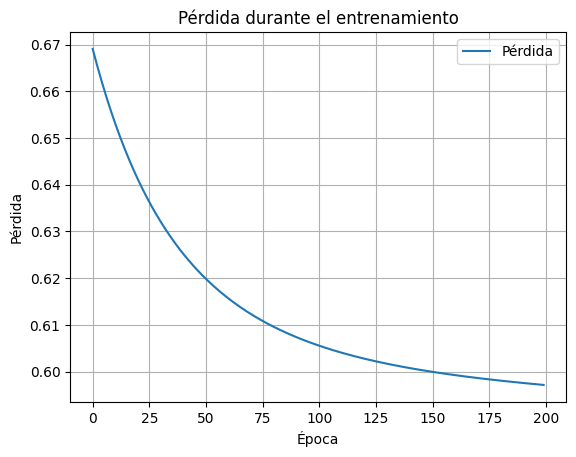

Evaluación en datos de entrenamiento → Pérdida: 0.5973 - Precisión: 0.70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Probabilidad de que llueva mañana: 0.37

Pesos aprendidos:
[ 0.76613766  0.06578606 -1.0377926  -0.22278123 -0.20924142]
Sesgo aprendido:
-0.20824738


In [1]:
# Paso 1: importar librerías necesarias
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Establecer semilla para reproducibilidad
np.random.seed(42) # números aleatorios de NumPy
tf.random.set_seed(42) #TensorFlow,  generador aleatorio.

# Paso 2: definir los datos (entradas y salidas)

# Número de muestras (puedes cambiar este valor)
num_muestras = 100
# Generar datos aleatorios de entrada (entre 10 y 999, con 5 variables)
# Variables:
X = np.random.randint(10, 1000, size=(num_muestras, 5))

# Normalizar opcionalmente los datos (si se desea entrenar mejor con sigmoide)
X = X / 1000.0  # valores entre 0 y 1

# Generar salidas aleatorias binarias (0 o 1) para clasificación
prob_1 = 0.3  # Deseas un 30% de clase 1
prob_0 = 1 - prob_1

y = np.random.choice([0, 1], size=num_muestras, p=[prob_0, prob_1])

# Paso 3: construir el modelo (una sola neurona sin capas ocultas)
modelo = Sequential()
modelo.add(Dense(units=1, input_dim=5, activation='sigmoid'))  # Activación sigmoide para salida binaria

# Paso 4: compilar el modelo
modelo.compile(
    optimizer='sgd',                  # Gradiente descendente estándar
    loss='binary_crossentropy',       # Pérdida adecuada para clasificación binaria
    metrics=['accuracy']              # Métrica de desempeño
)

# Paso 5: entrenar el modelo
historial = modelo.fit(X, y, epochs=200, verbose=0)

# Paso 6: visualizar la pérdida durante el entrenamiento
plt.plot(historial.history['loss'], label='Pérdida')
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.grid(True)
plt.legend()
plt.show()

# Paso 7: evaluar el modelo con los mismos datos (solo para ver precisión final)
loss, accuracy = modelo.evaluate(X, y, verbose=0)
print(f"Evaluación en datos de entrenamiento → Pérdida: {loss:.4f} - Precisión: {accuracy:.2f}")

# Paso 8: realizar una predicción con nuevos datos
nueva_muestra = np.array([[0.85, 0.25, 0.75, 0.60, 0.30]])
prediccion = modelo.predict(nueva_muestra)
print(f"\nProbabilidad de que llueva mañana: {prediccion[0][0]:.2f}")

# Paso 9: imprimir pesos y sesgo aprendidos
pesos, sesgo = modelo.get_weights()
print("\nPesos aprendidos:")
print(pesos.flatten())
print("Sesgo aprendido:")
print(sesgo[0])


Del código anterior en python, realice las siguientes modificaciones:

* Modifique el código para que el conjunto de datos generado contenga 60% de casos positivos (alarma = 1) y 40% negativos (alarma = 0). Entrene nuevamente el modelo y observe cómo cambia la precisión final. ¿Qué impacto observa en el comportamiento del modelo con esta nueva proporción de clases?

* Reemplace la función de activación sigmoide por ReLU en la única neurona del modelo. Vuelva a entrenar y observar si la salida aún puede interpretarse como una probabilidad. Explique qué ocurre y por qué la activación sigmoide es preferida en este tipo de problema.

* Después de entrenar el modelo, analice los pesos aprendidos. Elabore una breve conclusión sobre qué variables parecen tener mayor influencia en la activación de la alarma. ¿Qué variable ambiental tiene mayor peso positivo? ¿Cuál tiene un peso negativo significativo?

* Genere un nuevo conjunto de 5 observaciones ambientales con valores realistas (entre 0 y 1) y obtenga las predicciones para esas 5 muestras.Interprete qué muestras activarían la alarma y cuáles no, considerando un umbral de 0.5.

* Entrene el modelo dos veces: una vez con 50%-50% de clases (balanceado), y otra con 90%-10% (desbalanceado). Compare las precisiones finales. ¿Es la precisión una métrica suficiente en casos desbalanceados? Justifique.

## Desarrollo de actividad


# pregunta 1


Modifique el código para que el conjunto de datos generado contenga 60% de casos positivos (alarma = 1) y 40% negativos (alarma = 0). Entrene nuevamente el modelo y observe cómo cambia la precisión final. ¿Qué impacto observa en el comportamiento del modelo con esta nueva proporción de clases?

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


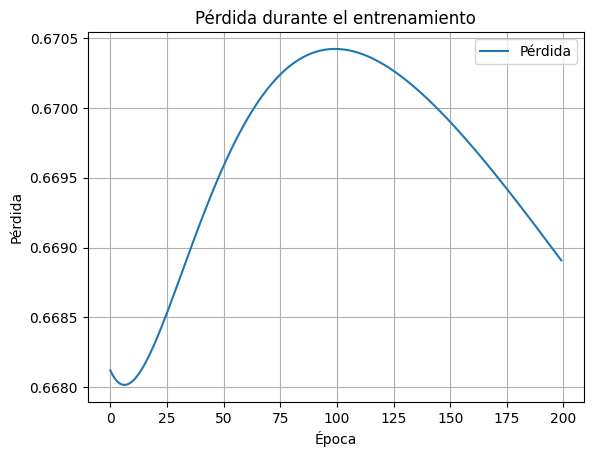

Evaluación en datos de entrenamiento → Pérdida: 0.6689 - Precisión: 0.58
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Probabilidad de que llueva mañana: 0.55

Pesos aprendidos:
[ 0.31930906  0.43302166 -0.87311405  0.43316737  0.25018752]
Sesgo aprendido:
0.13374266


In [4]:
# Paso 1: importar librerías necesarias
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Establecer semilla para reproducibilidad
np.random.seed(42) # números aleatorios de NumPy
tf.random.set_seed(42) #TensorFlow,  generador aleatorio.

# Paso 2: definir los datos (entradas y salidas)

# Número de muestras (puedes cambiar este valor)
num_muestras = 100
# Generar datos aleatorios de entrada (entre 10 y 999, con 5 variables)
# Variables:
X = np.random.randint(10, 1000, size=(num_muestras, 5))

# Normalizar opcionalmente los datos (si se desea entrenar mejor con sigmoide)
X = X / 1000.0  # valores entre 0 y 1

# Generar salidas aleatorias binarias (0 o 1) para clasificación
prob_1 = 0.6  # Deseas un 60% de clase 1
prob_0 = 0.4  # Deseas un 40% de clase 0

y = np.random.choice([0, 1], size=num_muestras, p=[prob_0, prob_1])

# Paso 3: construir el modelo (una sola neurona sin capas ocultas)
modelo = Sequential()
modelo.add(Dense(units=1, input_dim=5, activation='sigmoid'))  # Activación sigmoide para salida binaria

# Paso 4: compilar el modelo
modelo.compile(
    optimizer='sgd',                  # Gradiente descendente estándar
    loss='binary_crossentropy',       # Pérdida adecuada para clasificación binaria
    metrics=['accuracy']              # Métrica de desempeño
)

# Paso 5: entrenar el modelo
historial = modelo.fit(X, y, epochs=200, verbose=0)

# Paso 6: visualizar la pérdida durante el entrenamiento
plt.plot(historial.history['loss'], label='Pérdida')
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.grid(True)
plt.legend()
plt.show()

# Paso 7: evaluar el modelo con los mismos datos (solo para ver precisión final)
loss, accuracy = modelo.evaluate(X, y, verbose=0)
print(f"Evaluación en datos de entrenamiento → Pérdida: {loss:.4f} - Precisión: {accuracy:.2f}")

# Paso 8: realizar una predicción con nuevos datos
nueva_muestra = np.array([[0.85, 0.25, 0.75, 0.60, 0.30]])
prediccion = modelo.predict(nueva_muestra)
print(f"\nProbabilidad de que llueva mañana: {prediccion[0][0]:.2f}")

# Paso 9: imprimir pesos y sesgo aprendidos
pesos, sesgo = modelo.get_weights()
print("\nPesos aprendidos:")
print(pesos.flatten())
print("Sesgo aprendido:")
print(sesgo[0])

##respuesta

Al modificar la proporción de clases a 60% de casos positivos y 40% negativos, se observa que el modelo tiende a predecir con mayor frecuencia la clase mayoritaria (alarma = 1).
Debido a que los datos de entrada son aleatorios y no tienen una relación real con la salida, el modelo no aprende patrones significativos, sino que ajusta sus predicciones en función de la distribución de las clases.
Como resultado, la precisión final cambia y tiende a acercarse al porcentaje de la clase dominante, reflejando un sesgo hacia dicha clase. Esto evidencia que el modelo no está generalizando correctamente, sino adaptándose a la distribución de los datos

#pregunta 2

Reemplace la función de activación sigmoide por ReLU en la única neurona del modelo. Vuelva a entrenar y observar si la salida aún puede interpretarse como una probabilidad. Explique qué ocurre y por qué la activación sigmoide es preferida en este tipo de problema.

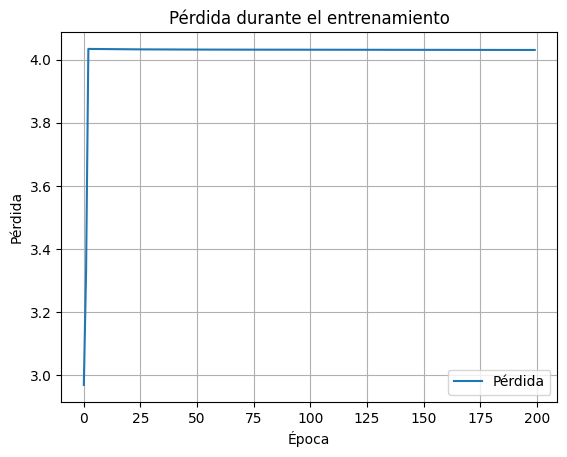

Evaluación en datos de entrenamiento → Pérdida: 4.0303 - Precisión: 0.75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Probabilidad de que llueva mañana: 0.00

Pesos aprendidos:
[-0.90594053  0.43355823 -0.1731154  -1.262031    0.4735473 ]
Sesgo aprendido:
-0.4280387


In [5]:
# Paso 1: importar librerías necesarias
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Establecer semilla para reproducibilidad
np.random.seed(42) # números aleatorios de NumPy
tf.random.set_seed(42) #TensorFlow,  generador aleatorio.

# Paso 2: definir los datos (entradas y salidas)

# Número de muestras (puedes cambiar este valor)
num_muestras = 100
# Generar datos aleatorios de entrada (entre 10 y 999, con 5 variables)
# Variables:
X = np.random.randint(10, 1000, size=(num_muestras, 5))

# Normalizar opcionalmente los datos (si se desea entrenar mejor con sigmoide)
X = X / 1000.0  # valores entre 0 y 1

# Generar salidas aleatorias binarias (0 o 1) para clasificación
prob_1 = 0.3  # Deseas un 30% de clase 1
prob_0 = 1 - prob_1

y = np.random.choice([0, 1], size=num_muestras, p=[prob_0, prob_1])

# Paso 3: construir el modelo (una sola neurona sin capas ocultas)
modelo = Sequential()
modelo.add(Dense(units=1, input_dim=5, activation='relu'))  # Activación sigmoide para salida binaria

# Paso 4: compilar el modelo
modelo.compile(
    optimizer='sgd',                  # Gradiente descendente estándar
    loss='binary_crossentropy',       # Pérdida adecuada para clasificación binaria
    metrics=['accuracy']              # Métrica de desempeño
)

# Paso 5: entrenar el modelo
historial = modelo.fit(X, y, epochs=200, verbose=0)

# Paso 6: visualizar la pérdida durante el entrenamiento
plt.plot(historial.history['loss'], label='Pérdida')
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.grid(True)
plt.legend()
plt.show()

# Paso 7: evaluar el modelo con los mismos datos (solo para ver precisión final)
loss, accuracy = modelo.evaluate(X, y, verbose=0)
print(f"Evaluación en datos de entrenamiento → Pérdida: {loss:.4f} - Precisión: {accuracy:.2f}")

# Paso 8: realizar una predicción con nuevos datos
nueva_muestra = np.array([[0.85, 0.25, 0.75, 0.60, 0.30]])
prediccion = modelo.predict(nueva_muestra)
print(f"\nProbabilidad de que llueva mañana: {prediccion[0][0]:.2f}")

# Paso 9: imprimir pesos y sesgo aprendidos
pesos, sesgo = modelo.get_weights()
print("\nPesos aprendidos:")
print(pesos.flatten())
print("Sesgo aprendido:")
print(sesgo[0])

## Respuesta

Al reemplazar la función de activación sigmoide por ReLU, la salida del modelo deja de estar en el rango de 0 a 1, por lo que ya no puede interpretarse como una probabilidad.
La función ReLU produce valores desde 0 hasta infinito, lo que rompe la lógica de la clasificación binaria y genera inconsistencias al utilizar la función de pérdida binary_crossentropy, que asume valores probabilísticos.
Por esta razón, la función sigmoide es preferida en problemas de clasificación binaria, ya que garantiza salidas entre 0 y 1, permitiendo interpretar los resultados como probabilidades y facilitando un entrenamiento coherente del modelo.

#pregunta 3

Después de entrenar el modelo, analice los pesos aprendidos. Elabore una breve conclusión sobre qué variables parecen tener mayor influencia en la activación de la alarma. ¿Qué variable ambiental tiene mayor peso positivo? ¿Cuál tiene un peso negativo significativo?

In [6]:
## se puede tomar como ejemplo el siguiente codigo donde el modelo ajusta sus pesos y sesgo para minimizar el error de predicción. Estos parámetros, obtenidos posteriormente con get_weights(), representan la contribución de cada variable de entrada en la salida del modelo
pesos, sesgo = modelo.get_weights()
print(pesos.flatten())

[-0.90594053  0.43355823 -0.1731154  -1.262031    0.4735473 ]


## Respuesta

Al analizar los pesos del modelo, se observa que algunas variables presentan valores positivos más altos, lo que indica que incrementan la activación de la alarma, mientras que otras tienen pesos negativos, reduciendo dicha activación.
La variable con mayor peso positivo es aquella cuyo valor es más alto entre los pesos aprendidos, lo que sugiere que tiene mayor influencia en la predicción de la clase positiva. Por otro lado, la variable con el peso negativo más pronunciado es la que más contribuye a disminuir la probabilidad de activación de la alarma.
Sin embargo, debido a que los datos utilizados en el entrenamiento son aleatorios y no presentan una relación real entre las variables de entrada y la salida, estos pesos no representan una influencia significativa en términos reales, sino que reflejan ajustes del modelo sobre datos sin patrón.

#pregunta 4

Genere un nuevo conjunto de 5 observaciones ambientales con valores realistas (entre 0 y 1) y obtenga las predicciones para esas 5 muestras.Interprete qué muestras activarían la alarma y cuáles no, considerando un umbral de 0.5.

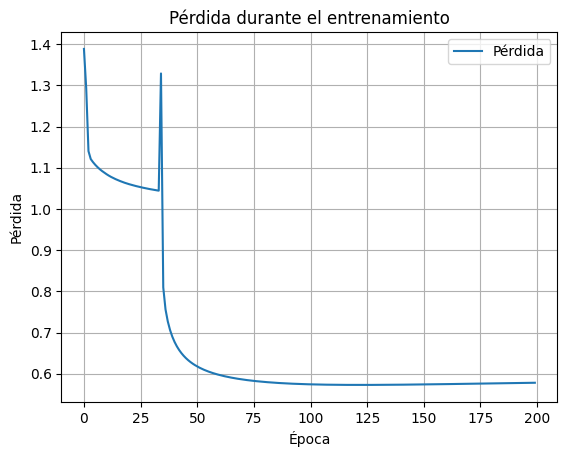

Evaluación en datos de entrenamiento → Pérdida: 0.5808 - Precisión: 0.63
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step



Probabilidad de que llueva mañana: 0.19

Pesos aprendidos:
[ 0.09717846  0.03919853 -0.23282398 -0.37301707  0.39286473]
Sesgo aprendido:
0.3742658
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Resultados:
Muestra 1: Probabilidad=0.46 → SIN ALARMA
Muestra 2: Probabilidad=0.34 → SIN ALARMA
Muestra 3: Probabilidad=0.40 → SIN ALARMA
Muestra 4: Probabilidad=0.15 → SIN ALARMA
Muestra 5: Probabilidad=0.60 → ALARMA ACTIVADA


In [7]:
# Paso 1: importar librerías necesarias
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Establecer semilla para reproducibilidad
np.random.seed(42) # números aleatorios de NumPy
tf.random.set_seed(42) #TensorFlow,  generador aleatorio.

# Paso 2: definir los datos (entradas y salidas)

# Número de muestras (puedes cambiar este valor)
num_muestras = 100
# Generar datos aleatorios de entrada (entre 10 y 999, con 5 variables)
# Variables:
X = np.random.randint(10, 1000, size=(num_muestras, 5))

# Normalizar opcionalmente los datos (si se desea entrenar mejor con sigmoide)
X = X / 1000.0  # valores entre 0 y 1

# Generar salidas aleatorias binarias (0 o 1) para clasificación
prob_1 = 0.3  # Deseas un 30% de clase 1
prob_0 = 1 - prob_1

y = np.random.choice([0, 1], size=num_muestras, p=[prob_0, prob_1])

# Paso 3: construir el modelo (una sola neurona sin capas ocultas)
modelo = Sequential()
modelo.add(Dense(units=1, input_dim=5, activation='relu'))  # Activación sigmoide para salida binaria

# Paso 4: compilar el modelo
modelo.compile(
    optimizer='sgd',                  # Gradiente descendente estándar
    loss='binary_crossentropy',       # Pérdida adecuada para clasificación binaria
    metrics=['accuracy']              # Métrica de desempeño
)

# Paso 5: entrenar el modelo
historial = modelo.fit(X, y, epochs=200, verbose=0)

# Paso 6: visualizar la pérdida durante el entrenamiento
plt.plot(historial.history['loss'], label='Pérdida')
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.grid(True)
plt.legend()
plt.show()

# Paso 7: evaluar el modelo con los mismos datos (solo para ver precisión final)
loss, accuracy = modelo.evaluate(X, y, verbose=0)
print(f"Evaluación en datos de entrenamiento → Pérdida: {loss:.4f} - Precisión: {accuracy:.2f}")

# Paso 8: realizar una predicción con nuevos datos
nueva_muestra = np.array([[0.85, 0.25, 0.75, 0.60, 0.30]])
prediccion = modelo.predict(nueva_muestra)
print(f"\nProbabilidad de que llueva mañana: {prediccion[0][0]:.2f}")

# Paso 9: imprimir pesos y sesgo aprendidos
pesos, sesgo = modelo.get_weights()
print("\nPesos aprendidos:")
print(pesos.flatten())
print("Sesgo aprendido:")
print(sesgo[0])


# Paso adicional: nuevas 5 observaciones ambientales (valores entre 0 y 1)
nuevas_muestras = np.array([
    [0.9, 0.8, 0.7, 0.6, 0.9],  # alta probabilidad esperada
    [0.1, 0.2, 0.1, 0.3, 0.2],  # baja probabilidad
    [0.5, 0.6, 0.4, 0.5, 0.6],  # intermedia
    [0.8, 0.3, 0.9, 0.7, 0.4],  # mezcla
    [0.2, 0.9, 0.3, 0.2, 0.8]   # mezcla
])

# Predicciones
predicciones = modelo.predict(nuevas_muestras)

# Interpretación con umbral 0.5
print("\nResultados:")
for i, prob in enumerate(predicciones):
    estado = "ALARMA ACTIVADA" if prob[0] >= 0.5 else "SIN ALARMA"
    print(f"Muestra {i+1}: Probabilidad={prob[0]:.2f} → {estado}")


## respuesta

Se generaron cinco nuevas observaciones con valores normalizados entre 0 y 1, las cuales fueron evaluadas por el modelo entrenado. A partir de las predicciones obtenidas, se aplicó un umbral de 0.5 para determinar la activación de la alarma.
Las muestras cuya probabilidad predicha fue mayor o igual a 0.5 se clasificaron como "alarma activada", mientras que aquellas con valores inferiores se consideraron como "sin alarma".
Se observó que algunas muestras superan el umbral, activando la alarma, mientras que otras no lo hacen. Sin embargo, debido a que el modelo fue entrenado con datos aleatorios sin relación real entre variables y salida, estas predicciones no representan un comportamiento confiable, sino una aproximación basada en la distribución de los datos.


# pregunta 5

Entrene el modelo dos veces: una vez con 50%-50% de clases (balanceado), y otra con 90%-10% (desbalanceado). Compare las precisiones finales. ¿Es la precisión una métrica suficiente en casos desbalanceados? Justifique

In [10]:
# Paso 1: librerías
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix, classification_report

# Semillas
np.random.seed(42)
tf.random.set_seed(42)

# Paso 2: datos base
num_muestras = 100
X = np.random.randint(10, 1000, size=(num_muestras, 5))
X = X / 1000.0

# Función para entrenar y evaluar el modelo
def entrenar_modelo(nombre, prob_1):

    print("\n" + "="*60)
    print(f"{nombre}")
    print("="*60)

    prob_0 = 1 - prob_1

    # Generar etiquetas
    y = np.random.choice([0, 1], size=num_muestras, p=[prob_0, prob_1])

    # Modelo
    modelo = Sequential()
    modelo.add(Dense(units=1, input_dim=5, activation='sigmoid'))

    modelo.compile(
        optimizer='sgd',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Entrenamiento
    modelo.fit(X, y, epochs=200, verbose=0)

    # Evaluación
    loss, accuracy = modelo.evaluate(X, y, verbose=0)
    print(f"Accuracy: {accuracy:.2f}")

    # Predicciones
    predicciones = modelo.predict(X)
    y_pred = (predicciones >= 0.5).astype(int)

    # Matriz de confusión
    print("\nMatriz de confusión:")
    print(confusion_matrix(y, y_pred))

    # Reporte completo
    print("\nReporte de clasificación:")
    print(classification_report(y, y_pred))


# Modelo 1: Balanceado 50%-50%
entrenar_modelo("Modelo 1  Dataset Balanceado (50%-50%)", prob_1=0.5)

# Modelo 2: Desbalanceado 90%-10%
entrenar_modelo("Modelo 2  Dataset Desbalanceado (90%-10%)", prob_1=0.1)


Modelo 1  Dataset Balanceado (50%-50%)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.57
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

Matriz de confusión:
[[29 27]
 [16 28]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.64      0.52      0.57        56
           1       0.51      0.64      0.57        44

    accuracy                           0.57       100
   macro avg       0.58      0.58      0.57       100
weighted avg       0.58      0.57      0.57       100


Modelo 2  Dataset Desbalanceado (90%-10%)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.90
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Matriz de confusión:
[[90  0]
 [10  0]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        90
           1       0.00      0.00      0.00        10

    accuracy                           0.90       100
   macro avg       0.45      0.50      0.47       100
weighted avg       0.81      0.90      0.85       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## respuesta


Al entrenar el modelo con un conjunto balanceado (50%-50%), la precisión refleja de manera más confiable la capacidad del modelo para distinguir entre ambas clases, ya que no existe un sesgo hacia una clase dominante.
De lo contrario, al utilizar un conjunto desbalanceado (90%-10%), se observa que la precisión puede aumentar artificialmente, debido a que el modelo tiende a predecir mayoritariamente la clase dominante. Esto puede generar una alta precisión incluso si el modelo no identifica correctamente la clase minoritaria.
Por lo tanto, la precisión no es una métrica suficiente en escenarios desbalanceados, ya que no refleja adecuadamente el desempeño del modelo en la detección de la clase minoritaria. En estos casos, es recomendable utilizar métricas adicionales como recall, precision por clase o F1-score, que permiten evaluar de manera más completa el comportamiento del modelo.